laod and generate weather

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from feature_store.engineer import build_features, get_feature_columns
from feature_store.sources.weather import generate_simulated_weather
from model.evaluate import compute_wmape

# Load sales data
DATA_RAW = Path(r"C:\Users\syeds\OneDrive\Desktop\nboracle\nb_oracle\data\raw\store-sales-time-series-forecasting")
train = pd.read_csv(DATA_RAW / "train.csv", parse_dates=["date"])
holidays = pd.read_csv(DATA_RAW / "holidays_events.csv", parse_dates=["date"])

store44 = train[train.store_nbr == 44].copy()
bev = (store44[store44.family == "BEVERAGES"]
       .sort_values("date").reset_index(drop=True))

# Generate weather data for all dates in our dataset
all_dates = train["date"].sort_values().unique()
weather = generate_simulated_weather(all_dates)

print(f"Generated weather for {len(weather)} days")
print(f"\nSample weather data:")
print(weather.head(10).to_string(index=False))

Generated weather for 1684 days

Sample weather data:
      date  temp_high  temp_feels_like  precipitation_mm  is_precipitation  humidity
2013-01-01       63.6             64.2               0.0                 0      63.0
2013-01-02       60.8             62.6               0.0                 0      87.0
2013-01-03       64.3             65.3               0.0                 0      70.0
2013-01-04       68.3             69.6               0.0                 0      77.0
2013-01-05       60.4             61.8               3.0                 1      78.0
2013-01-06       60.5             61.6               3.7                 1      72.0
2013-01-07       68.7             70.2               0.0                 0      81.0
2013-01-08       65.0             66.1               0.0                 0      70.0
2013-01-09       59.5             61.2               4.1                 1      84.0
2013-01-10       64.1             64.7              23.5                 1      62.0


look at the weather data

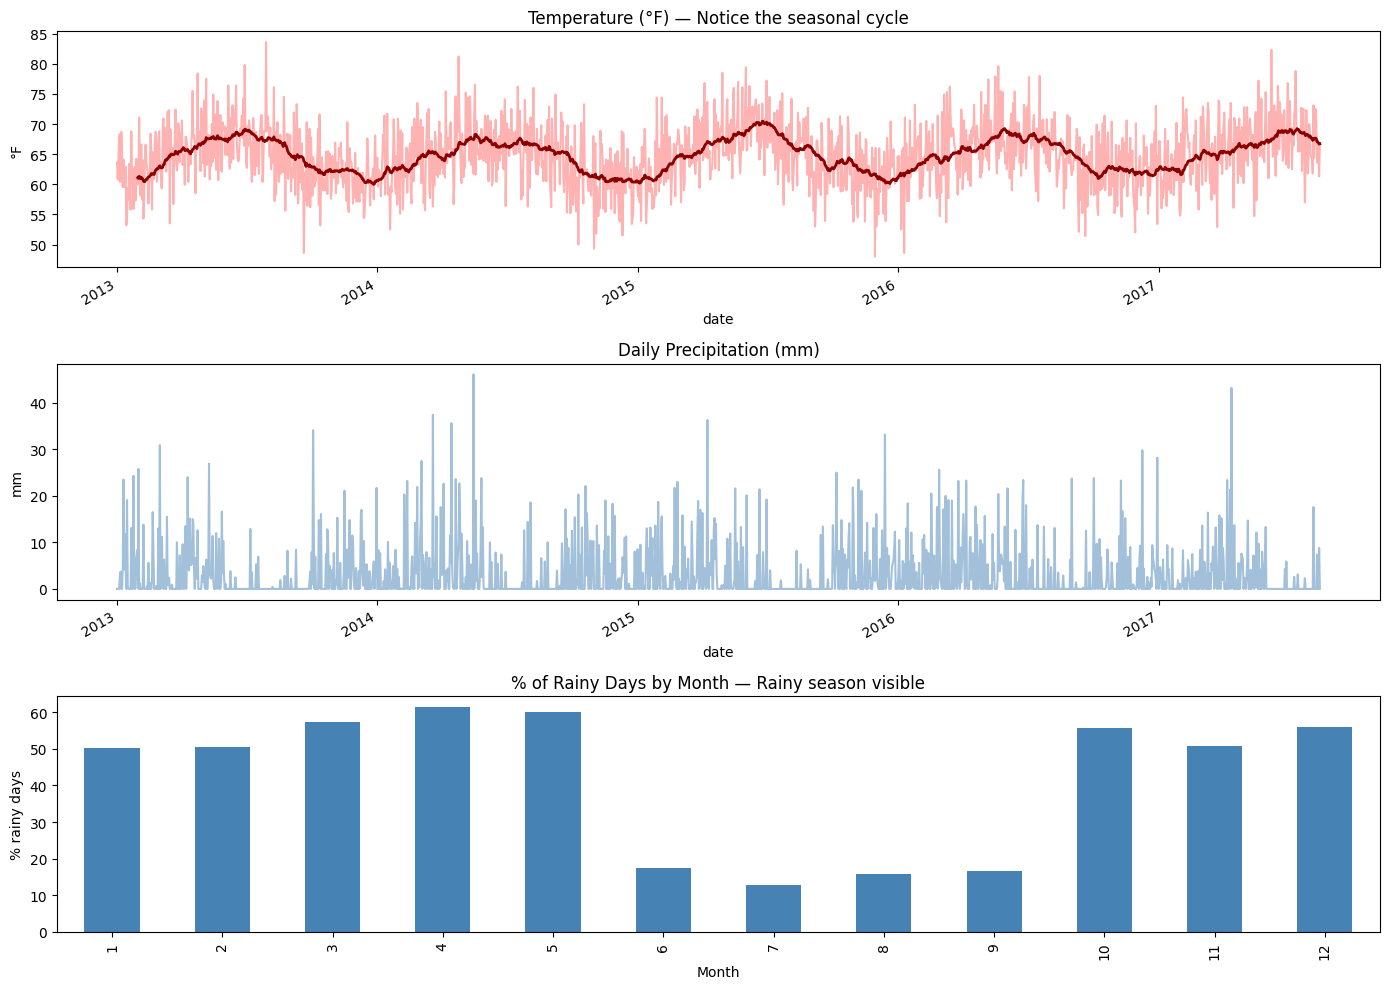

In [2]:
# Let's see what our simulated weather looks like
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

weather_plot = weather.set_index("date")

# Temperature over time
weather_plot["temp_high"].plot(ax=axes[0], alpha=0.3, color="red")
weather_plot["temp_high"].rolling(30).mean().plot(ax=axes[0], color="darkred", linewidth=2)
axes[0].set_title("Temperature (°F) — Notice the seasonal cycle")
axes[0].set_ylabel("°F")

# Precipitation
weather_plot["precipitation_mm"].plot(ax=axes[1], alpha=0.5, color="steelblue")
axes[1].set_title("Daily Precipitation (mm)")
axes[1].set_ylabel("mm")

# Rainy vs dry days per month
monthly_rain = weather.groupby(weather["date"].dt.month)["is_precipitation"].mean() * 100
monthly_rain.plot(kind="bar", ax=axes[2], color="steelblue")
axes[2].set_title("% of Rainy Days by Month — Rainy season visible")
axes[2].set_ylabel("% rainy days")
axes[2].set_xlabel("Month")

plt.tight_layout()
plt.show()

build features with wheather and compare

In [3]:
# Build features WITHOUT weather (our previous model)
features_no_weather = build_features(bev, holidays).dropna()

# Build features WITH weather
features_with_weather = build_features(bev, holidays, weather_df=weather).dropna()

print(f"Features WITHOUT weather: {len(get_feature_columns(features_no_weather))} columns")
print(f"Features WITH weather:    {len(get_feature_columns(features_with_weather))} columns")

new_features = set(get_feature_columns(features_with_weather)) - set(get_feature_columns(features_no_weather))
print(f"\nNew weather features added:")
for f in sorted(new_features):
    print(f"  • {f}")

Features WITHOUT weather: 14 columns
Features WITH weather:    24 columns

New weather features added:
  • is_cold_day
  • is_hot_day
  • is_precipitation
  • precipitation_mm
  • rain_streak_days
  • temp_delta_vs_weekly_avg
  • temp_delta_vs_yesterday
  • temp_feels_like
  • temp_high
  • weather_severity


train both models and compare

In [4]:
SPLIT_DATE = "2017-07-15"

# === Model WITHOUT weather ===
train_nw = features_no_weather[features_no_weather.index < SPLIT_DATE]
test_nw = features_no_weather[features_no_weather.index >= SPLIT_DATE]
feat_cols_nw = get_feature_columns(features_no_weather)

model_no_weather = xgb.XGBRegressor(
    objective="reg:tweedie", tweedie_variance_power=1.6,
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.7, min_child_weight=10,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42,
    early_stopping_rounds=30)

model_no_weather.fit(
    train_nw[feat_cols_nw], train_nw["sales"],
    eval_set=[(test_nw[feat_cols_nw], test_nw["sales"])],
    verbose=False)

pred_no_weather = np.maximum(model_no_weather.predict(test_nw[feat_cols_nw]), 0)
wmape_no_weather = compute_wmape(test_nw["sales"].values, pred_no_weather)

# === Model WITH weather ===
train_w = features_with_weather[features_with_weather.index < SPLIT_DATE]
test_w = features_with_weather[features_with_weather.index >= SPLIT_DATE]
feat_cols_w = get_feature_columns(features_with_weather)

model_with_weather = xgb.XGBRegressor(
    objective="reg:tweedie", tweedie_variance_power=1.6,
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.7, min_child_weight=10,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42,
    early_stopping_rounds=30)

model_with_weather.fit(
    train_w[feat_cols_w], train_w["sales"],
    eval_set=[(test_w[feat_cols_w], test_w["sales"])],
    verbose=False)

pred_with_weather = np.maximum(model_with_weather.predict(test_w[feat_cols_w]), 0)
wmape_with_weather = compute_wmape(test_w["sales"].values, pred_with_weather)

# === Results ===
print("=" * 55)
print("   MODEL COMPARISON: With vs Without Weather")
print("=" * 55)
print(f"  Baseline (4-week avg):    {0.1502:.4f} (15.0%)")
print(f"  XGBoost WITHOUT weather:  {wmape_no_weather:.4f} ({wmape_no_weather*100:.1f}%)")
print(f"  XGBoost WITH weather:     {wmape_with_weather:.4f} ({wmape_with_weather*100:.1f}%)")
print("=" * 55)

if wmape_with_weather < wmape_no_weather:
    improvement = (wmape_no_weather - wmape_with_weather) / wmape_no_weather * 100
    print(f"  ✅ Weather features improved the model by {improvement:.1f}%!")
else:
    print("  ⚠️  Weather didn't help (expected with simulated data)")
    print("  Real weather data should show more improvement.")

   MODEL COMPARISON: With vs Without Weather
  Baseline (4-week avg):    0.1502 (15.0%)
  XGBoost WITHOUT weather:  0.1319 (13.2%)
  XGBoost WITH weather:     0.1302 (13.0%)
  ✅ Weather features improved the model by 1.3%!


seeing weather features the model is actually using

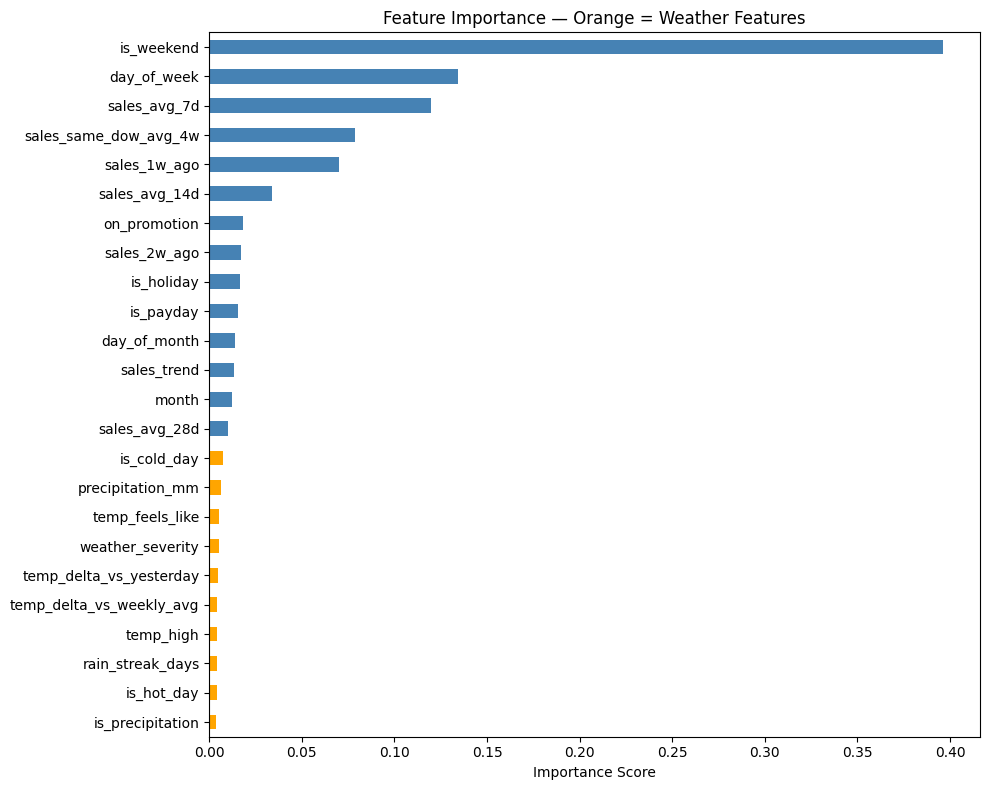


Weather feature importance:
  • is_cold_day: 0.0073
  • is_hot_day: 0.0040
  • is_precipitation: 0.0035
  • precipitation_mm: 0.0063
  • rain_streak_days: 0.0043
  • temp_delta_vs_weekly_avg: 0.0043
  • temp_delta_vs_yesterday: 0.0047
  • temp_feels_like: 0.0053
  • temp_high: 0.0043
  • weather_severity: 0.0050


In [5]:
importance = pd.Series(
    model_with_weather.feature_importances_,
    index=feat_cols_w
).sort_values(ascending=True)

# Highlight weather features in the chart
colors = ["orange" if f in new_features else "steelblue" for f in importance.index]

fig, ax = plt.subplots(figsize=(10, 8))
importance.plot(kind="barh", ax=ax, color=colors)
ax.set_title("Feature Importance — Orange = Weather Features")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("\nWeather feature importance:")
for f in sorted(new_features):
    score = importance.get(f, 0)
    print(f"  • {f}: {score:.4f}")

 Updated SHAP explanations with weather context:

In [6]:
import shap

explainer = shap.TreeExplainer(model_with_weather)
shap_values = explainer.shap_values(test_w[feat_cols_w])

# Pick the highest sales day
idx = test_w["sales"].values.argmax()
date = test_w.index[idx]
actual = test_w["sales"].values[idx]
predicted = pred_with_weather[idx]

print(f"Highest sales day: {date.date()}")
print(f"Actual: {actual:,.0f}  |  Predicted: {predicted:,.0f}")
print(f"\nTop influences on this prediction:")
print("=" * 55)

day_shap = pd.Series(shap_values[idx], index=feat_cols_w)
top_features = day_shap.abs().nlargest(8)

for feat in top_features.index:
    val = test_w[feat].iloc[idx]
    sv = day_shap[feat]
    direction = "↑" if sv > 0 else "↓"
    is_weather = " 🌤️" if feat in new_features else ""
    print(f"  {direction} {feat:<28s} = {val:>8.1f}  (impact: {sv:>+8.0f}){is_weather}")

Highest sales day: 2017-07-30
Actual: 18,340  |  Predicted: 13,587

Top influences on this prediction:
  ↑ day_of_week                  =      6.0  (impact:       +0)
  ↑ sales_avg_7d                 =  10291.6  (impact:       +0)
  ↑ sales_1w_ago                 =  14396.0  (impact:       +0)
  ↑ sales_same_dow_avg_4w        =  16025.2  (impact:       +0)
  ↑ is_weekend                   =      1.0  (impact:       +0)
  ↑ sales_avg_14d                =  10612.6  (impact:       +0)
  ↑ sales_2w_ago                 =  16317.0  (impact:       +0)
  ↑ sales_avg_28d                =  10858.1  (impact:       +0)
